#Repair Priority Ranker

 This notebook takes a list of aircraft parts from a Beoing 777 that are currently sitting in stock needing repair, and figures out which ones are worth fixing first. It does this by running each part through a pre-trained CatBoost model that predicts the probability of that part selling within 60 days. Parts are then ranked from most to least likely to sell, and grouped into High, Medium, or Low priority tiers. It also explains why each part got its score using SHAP values, which highlight the top features driving each prediction. The final output is a ranked CSV file that tells a repair team exactly where to focus their effort first.

# Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/FourthYear/Dissertation

/content/drive/MyDrive/FourthYear/Dissertation


In [3]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


Necessary items are loaded

In [4]:
import pandas as pd
import numpy as np
import shap
import joblib
from catboost import CatBoostClassifier, Pool

model     = CatBoostClassifier()
model.load_model("best_catboost_model.cbm")
imputer   = joblib.load("median_imputer.pkl")
cat_feats = joblib.load("cat_features.pkl")

df_complete = pd.read_csv("complete_dataset.csv")

Load Stock List and filter to AR

In [5]:
df_stock = pd.read_excel("777 Parts List.xlsx", skiprows=1)
df_stock.columns = ['drop', 'part_number', 'description', 'condition', 'quantity']
df_stock = df_stock.drop(columns=['drop'])

df_ar = df_stock[df_stock['condition'] == 'AR'].copy()
print(f"Total AR parts in stock list : {len(df_ar)}")
print(f"Unique AR part numbers       : {df_ar['part_number'].nunique()}")

Total AR parts in stock list : 1738
Unique AR part numbers       : 825


# Parts taken from Complete Dataset

Matches each AR part number against the complete dataset to retrieve its demand features. Unmatched parts are reported and excluded. Where a part appears multiple times, the most recent record is kept.

In [6]:
ar_pns = df_ar['part_number'].astype(str).unique()
df_matched = df_complete[
    df_complete['item_part_number'].astype(str).isin(ar_pns)
].copy()

print(f"AR PNs in stock list          : {len(ar_pns)}")
print(f"AR PNs found in dataset       : {df_matched['item_part_number'].nunique()}")
print(f"AR PNs NOT found in dataset   : {len(ar_pns) - df_matched['item_part_number'].nunique()}")

df_matched['received_date'] = pd.to_datetime(df_matched['received_date'], errors='coerce')

df_matched = (
    df_matched
    .sort_values('received_date', ascending=False)
    .drop_duplicates(subset='item_part_number', keep='first')
    .reset_index(drop=True)
)

print(f"\nParts available for scoring   : {len(df_matched)}")

AR PNs in stock list          : 825
AR PNs found in dataset       : 136
AR PNs NOT found in dataset   : 689

Parts available for scoring   : 136


Applies the same preprocessing steps used during training, missing categoricals are filled, ADI and CV2 are imputed, and all categorical columns are cast to the correct type.


In [7]:
df_scored = df_matched.drop(columns=['sold_within_60d'], errors='ignore').copy()

unknown_cols = ['primary_platform_family', 'ata_groups', 'url_ata_chapter']
df_scored[unknown_cols] = df_scored[unknown_cols].fillna('unknown')
df_scored[['adi', 'cv2']] = imputer.transform(df_scored[['adi', 'cv2']])

for col in cat_feats:
    if col in df_scored.columns:
        df_scored[col] = df_scored[col].fillna('unknown').astype(str).astype('category')

Builds the feature matrix using the 21 columns the model was trained on and validates that no float values remain in categorical columns before scoring.


In [8]:
feature_cols = [
    'adi', 'cv2', 'ata_groups', 'platform_type', 'url_ata_chapter',
    'non_zero_periods', 'demand_type', 'sales_count_60d', 'sales_count_90d',
    'sales_count_180d', 'sales_count_365d', 'primary_platform_family',
    'boeing_717_flag', 'boeing_737_flag', 'boeing_747_flag', 'boeing_757_flag',
    'boeing_767_flag', 'boeing_777_flag', 'boeing_787_flag',
    'boeing_family_count', 'platform_applicability_count'
]

X_apply = df_scored[feature_cols].copy()

for col in cat_feats:
    if col in X_apply.columns:
        X_apply[col] = X_apply[col].astype(object).fillna('unknown').astype(str).astype('category')

problem_cols = [
    col for col in cat_feats
    if col in X_apply.columns and isinstance(X_apply[col].iloc[0], float)
]

if problem_cols:
    print(f"WARNING — float values remain in: {problem_cols}")
else:
    print("All categorical columns clean — safe to score")

All categorical columns clean — safe to score


# Scored and Ranked

Passes the feature matrix to the trained CatBoost model. The output prob_sale_60d is the estimated probability that each part will sell within 60 days.


In [9]:
apply_pool = Pool(
    data=X_apply,
    cat_features=[col for col in cat_feats if col in X_apply.columns]
)

df_scored['prob_sale_60d'] = model.predict_proba(apply_pool)[:, 1]

In [10]:
explainer    = shap.TreeExplainer(model)
shap_values  = explainer.shap_values(apply_pool)
feature_names = X_apply.columns.tolist()

def get_top_drivers(shap_row, feature_names, n=3):
    top_idx = np.argsort(np.abs(shap_row))[::-1][:n]
    drivers = []
    for i in top_idx:
        direction = "+" if shap_row[i] > 0 else "-"
        drivers.append(f"{feature_names[i]} ({direction}{abs(shap_row[i]):.3f})")
    return drivers

df_scored['top_drivers'] = [
    get_top_drivers(shap_values[i], feature_names)
    for i in range(len(df_scored))
]

Parts are ranked by sale probability and assigned a priority tier — High (above 0.6), Medium (0.3–0.6), or Low (below 0.3).

In [11]:
top_drivers_list = [
    get_top_drivers(shap_values[i], feature_names)
    for i in range(len(df_scored))
]

top_drivers_df = pd.DataFrame(top_drivers_list, columns=[
    "top_driver_1", "top_driver_2", "top_driver_3"
])

df_scored = pd.concat([df_scored, top_drivers_df], axis=1)

# Ranked Repair List Outputted
Parts are ranked by sale probability and assigned a priority tier — High (above 0.6), Medium (0.3–0.6), or Low (below 0.3).

In [12]:
df_scored = df_scored.sort_values('prob_sale_60d', ascending=False).reset_index(drop=True)
df_scored['repair_priority_rank'] = df_scored.index + 1

df_scored['priority_tier'] = pd.cut(
    df_scored['prob_sale_60d'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

output_cols = [
    'repair_priority_rank', 'item_part_number', 'prob_sale_60d',
    'priority_tier', "top_driver_1", "top_driver_2", "top_driver_3"
]

df_scored[output_cols].to_csv("ranked_repair_list.csv", index=False)

In [13]:
df_scored[output_cols]

,repair_priority_rank,item_part_number,prob_sale_60d,priority_tier,top_driver_1,top_driver_2,top_driver_3
0,1,3510-0044-05,0.924283,High,sales_count_365d (+2.846),boeing_family_count (+0.594),non_zero_periods (-0.418)
1,2,4100941D,0.922651,High,sales_count_365d (+2.425),boeing_family_count (+0.531),cv2 (-0.375)
2,3,S67-2002-18,0.921537,High,sales_count_365d (+2.431),url_ata_chapter (+0.564),boeing_family_count (+0.454)
3,4,622-8849-100,0.821251,High,sales_count_365d (+1.209),ata_groups (+0.415),sales_count_180d (+0.253)
4,5,RD-KA1003-05,0.808976,High,sales_count_365d (+1.462),url_ata_chapter (+0.692),sales_count_180d (+0.332)
...,...,...,...,...,...,...,...
131,132,3215922-3,0.082589,Low,ata_groups (-0.327),sales_count_365d (-0.324),url_ata_chapter (-0.215)
132,133,4321561,0.076099,Low,non_zero_periods (-0.357),sales_count_365d (-0.319),url_ata_chapter (-0.185)
133,134,4404B000-004,0.048182,Low,ata_groups (-0.888),url_ata_chapter (-0.354),non_zero_periods (-0.342)
134,135,2040061-103,0.043947,Low,ata_groups (-0.987),sales_count_365d (-0.345),non_zero_periods (-0.331)


#Analysis of List

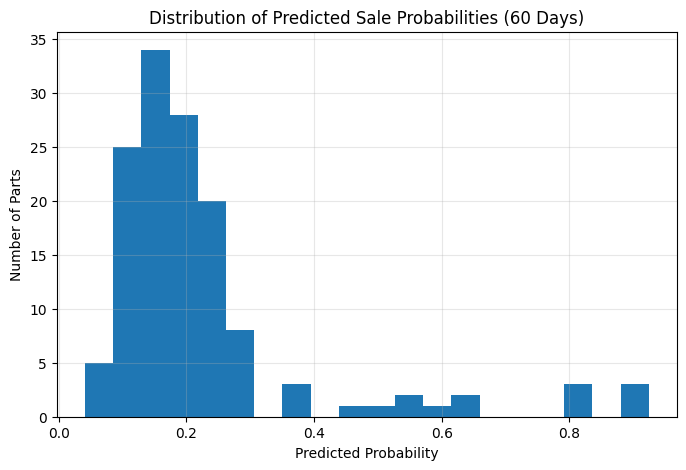

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df_scored['prob_sale_60d'], bins=20)

plt.title('Distribution of Predicted Sale Probabilities (60 Days)')
plt.xlabel('Predicted Probability')
plt.ylabel('Number of Parts')

plt.grid(alpha=0.3)
plt.show()

In [15]:

ata_dist = (
    df_scored.groupby(['priority_tier', 'ata_groups'])
    .size()
    .reset_index(name='count')
)

# Convert to % within each tier
ata_dist['percentage'] = ata_dist.groupby('priority_tier')['count'].transform(lambda x: x / x.sum())

print("ATA Group distribution by priority tier:")
display(ata_dist.sort_values(['priority_tier', 'percentage'], ascending=[True, False]))

ATA Group distribution by priority tier:


/tmp/ipykernel_17951/1934637463.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_scored.groupby(['priority_tier', 'ata_groups'])
/tmp/ipykernel_17951/1934637463.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ata_dist['percentage'] = ata_dist.groupby('priority_tier')['count'].transform(lambda x: x / x.sum())


,priority_tier,ata_groups,count,percentage
0,Low,AIRCRAFT SYSTEMS,92,0.793103
2,Low,STRUCTURE,12,0.103448
3,Low,unknown,10,0.086207
1,Low,POWER PLANT,2,0.017241
4,Medium,AIRCRAFT SYSTEMS,11,1.000000
5,Medium,POWER PLANT,0,0.000000
6,Medium,STRUCTURE,0,0.000000
7,Medium,unknown,0,0.000000
8,High,AIRCRAFT SYSTEMS,8,0.888889
10,High,STRUCTURE,1,0.111111


In [16]:
demand_dist = (
    df_scored.groupby(['priority_tier', 'demand_type'])
    .size()
    .reset_index(name='count')
)

demand_dist['percentage'] = demand_dist.groupby('priority_tier')['count'].transform(lambda x: x / x.sum())

print("Demand Type distribution by priority tier:")
display(demand_dist.sort_values(['priority_tier', 'percentage'], ascending=[True, False]))

/tmp/ipykernel_17951/367683708.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_scored.groupby(['priority_tier', 'demand_type'])
/tmp/ipykernel_17951/367683708.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  demand_dist['percentage'] = demand_dist.groupby('priority_tier')['count'].transform(lambda x: x / x.sum())


Demand Type distribution by priority tier:


,priority_tier,demand_type,count,percentage
1,Low,Insufficient Data,78,0.672414
2,Low,Intermittent,23,0.198276
4,Low,Smooth,7,0.060345
3,Low,Lumpy,6,0.051724
0,Low,Erratic,2,0.017241
6,Medium,Insufficient Data,4,0.363636
7,Medium,Intermittent,4,0.363636
5,Medium,Erratic,1,0.090909
8,Medium,Lumpy,1,0.090909
9,Medium,Smooth,1,0.090909


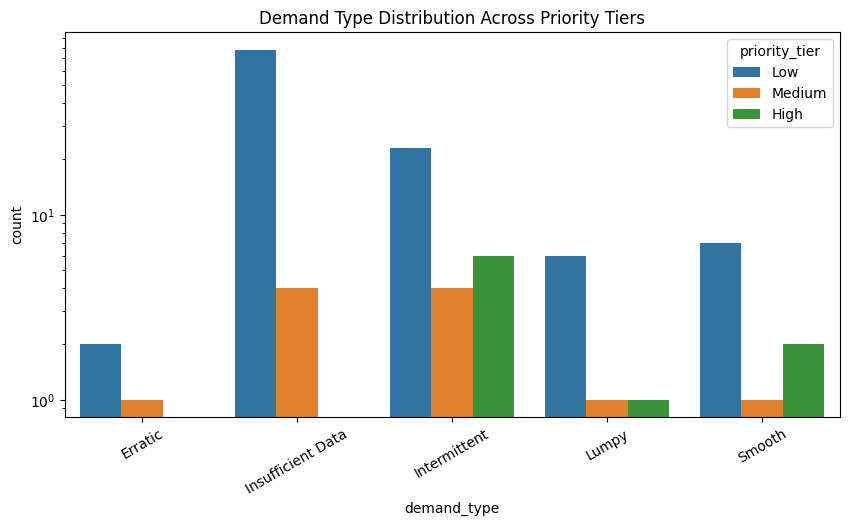

In [17]:
import seaborn as sns

# Demand Type plot
plt.figure(figsize=(10, 5))
sns.countplot(data=df_scored, x='demand_type', hue='priority_tier')

plt.title('Demand Type Distribution Across Priority Tiers')
plt.yscale('log')
plt.xticks(rotation=30)
plt.show()

In [18]:
import matplotlib.ticker as mticker

### High Tier Characteristics

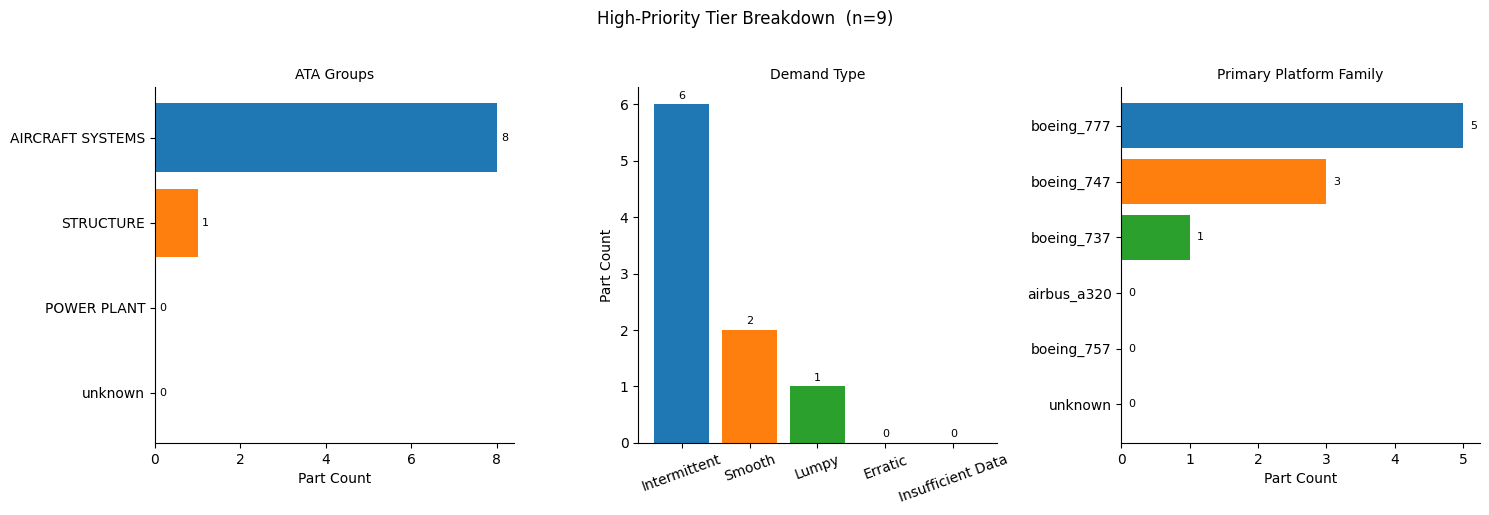

In [19]:
df_high = df_scored[df_scored['priority_tier'] == 'High'].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f"High-Priority Tier Breakdown  (n={len(df_high)})",
    fontsize=12, y=1.02
)

PALETTE = plt.cm.tab10.colors

# — ATA Groups —
ata_counts = df_high['ata_groups'].value_counts()
axes[0].barh(ata_counts.index, ata_counts.values,
             color=PALETTE[:len(ata_counts)])
axes[0].invert_yaxis()
axes[0].set_title("ATA Groups", fontsize=10)
axes[0].set_xlabel("Part Count")
axes[0].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(ata_counts.values):
    axes[0].text(v + 0.1, i, str(v), va='center', fontsize=8)

# — Demand Type —
demand_counts = df_high['demand_type'].value_counts()
axes[1].bar(demand_counts.index, demand_counts.values,
            color=PALETTE[:len(demand_counts)])
axes[1].set_title("Demand Type", fontsize=10)
axes[1].set_ylabel("Part Count")
axes[1].tick_params(axis='x', rotation=20)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for i, (label, v) in enumerate(demand_counts.items()):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=8)

# — Platform Family —
plat_counts = df_high['primary_platform_family'].value_counts()
axes[2].barh(plat_counts.index, plat_counts.values,
             color=PALETTE[:len(plat_counts)])
axes[2].invert_yaxis()
axes[2].set_title("Primary Platform Family", fontsize=10)
axes[2].set_xlabel("Part Count")
axes[2].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(plat_counts.values):
    axes[2].text(v + 0.1, i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.savefig("high_tier_characteristics.png", dpi=150, bbox_inches='tight')
plt.show()



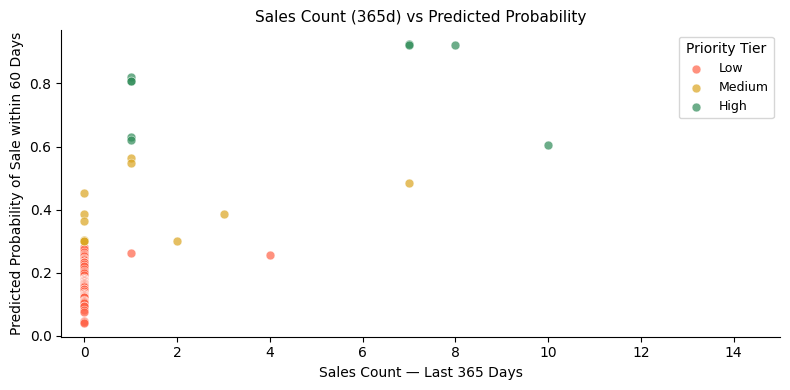

In [20]:
# Sales Velocity vs Score


fig, ax = plt.subplots(figsize=(8, 4))

tier_colours = {'High': 'seagreen', 'Medium': 'goldenrod', 'Low': 'tomato'}

for tier, grp in df_scored.groupby('priority_tier', observed=True):
    ax.scatter(
        grp['sales_count_365d'],
        grp['prob_sale_60d'],
        label=tier,
        color=tier_colours.get(str(tier), 'grey'),
        alpha=0.7,
        s=40,
        edgecolors='white',
        linewidths=0.4
    )

ax.set_title("Sales Count (365d) vs Predicted Probability", fontsize=11)
ax.set_xlabel("Sales Count — Last 365 Days", fontsize=10)
ax.set_ylabel("Predicted Probability of Sale within 60 Days", fontsize=10)
ax.set_xlim(-.5, 15)
ax.legend(title="Priority Tier", fontsize=9)
ax.spines[['top', 'right']].set_visible(False)


plt.tight_layout()
plt.savefig("sales_vs_score.png", dpi=150, bbox_inches='tight')
plt.show()

### Feature Importance by Priority Tier
For each priority tier, compute the mean absolute SHAP value per feature.
Features are ordered by their overall mean |SHAP| so the most globally important features appear at the top.

/tmp/ipykernel_17951/3276818103.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('priority_tier')[feature_names]


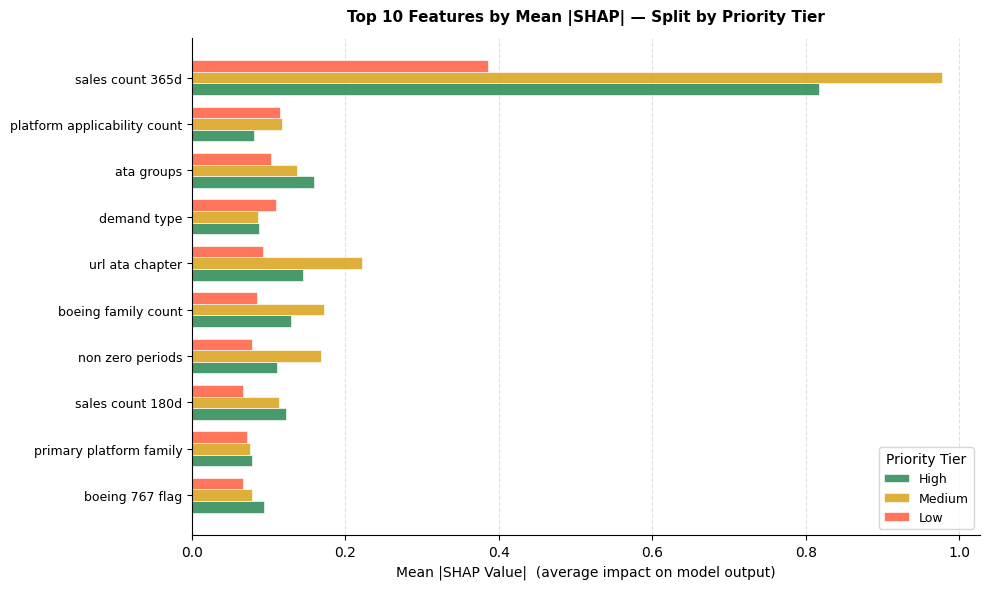

In [21]:

TIERS        = ['High', 'Medium', 'Low']
TIER_COLOURS = {'High': 'seagreen', 'Medium': 'goldenrod', 'Low': 'tomato'}
TOP_N        = 10   #

# Build a DataFrame of SHAP values aligned with df_scored index
shap_abs = pd.DataFrame(
    np.abs(shap_values),
    columns=feature_names,
    index=df_scored.index
)
shap_abs['priority_tier'] = df_scored['priority_tier'].values

# Mean SHAP per tier
tier_importance = (
    shap_abs
    .groupby('priority_tier')[feature_names]
    .mean()
)

# Overall mean SHAP — used to rank features
overall_mean = shap_abs[feature_names].mean().sort_values(ascending=False)
top_features = overall_mean.head(TOP_N).index.tolist()

# Subset and reverse so highest-importance feature is at the top of the chart
tier_importance_top = tier_importance[top_features].T
tier_importance_top = tier_importance_top.loc[top_features[::-1]]

#plot
n_features = len(top_features)
bar_height  = 0.25
y_pos       = np.arange(n_features)

fig, ax = plt.subplots(figsize=(10, 6))

for i, tier in enumerate(TIERS):
    if tier not in tier_importance_top.columns:
        continue
    offset = (i - 1) * bar_height          # centres the three bars around each tick
    ax.barh(
        y_pos + offset,
        tier_importance_top[tier],
        height=bar_height,
        label=tier,
        color=TIER_COLOURS[tier],
        edgecolor='white',
        linewidth=0.5,
        alpha=0.88
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(
    [f.replace('_', ' ') for f in tier_importance_top.index],
    fontsize=9
)
ax.set_xlabel("Mean |SHAP Value|  (average impact on model output)", fontsize=10)
ax.set_title(
    f"Top {TOP_N} Features by Mean |SHAP| — Split by Priority Tier",
    fontsize=11, fontweight='bold', pad=12
)
ax.legend(title="Priority Tier", fontsize=9, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("shap_by_tier.png", dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Strip the direction so we just have the feature name

df_scored['top_driver_1_name'] = (
    df_scored['top_driver_1']
    .str.extract(r'^([^\s(]+)')   # everything before the first space or bracket
)

tiers = ['High', 'Medium', 'Low']

frames = {}
for tier in tiers:
    subset = df_scored[df_scored['priority_tier'] == tier]
    counts = subset['top_driver_1_name'].value_counts()
    frames[tier] = (counts / counts.sum() * 100).round(1)

table = (
    pd.DataFrame(frames)
    .fillna(0.0)
    .sort_values('High', ascending=False)
)

# Format as strings with % sign
table = table.applymap(lambda x: f"{x:.1f}%")
table.index.name = 'Top Driver #1 Feature'

print("% of Parts Where Feature Was the #1 SHAP Driver\n")
print(table.to_string())

% of Parts Where Feature Was the #1 SHAP Driver

                                High Medium    Low
Top Driver #1 Feature                             
sales_count_365d              100.0%  72.7%  84.5%
ata_groups                      0.0%   9.1%   5.2%
boeing_787_flag                 0.0%  18.2%   0.0%
boeing_717_flag                 0.0%   0.0%   2.6%
boeing_family_count             0.0%   0.0%   1.7%
non_zero_periods                0.0%   0.0%   3.4%
platform_applicability_count    0.0%   0.0%   1.7%
url_ata_chapter                 0.0%   0.0%   0.9%


/tmp/ipykernel_17951/2374562126.py:23: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  table = table.applymap(lambda x: f"{x:.1f}%")
